# Task 6: Movie Ratings Analysis
**Python Visualization Project**

Analyze a dataset of 650 movies using Pandas, Matplotlib, and Seaborn. The objective is to create 5+ visualizations covering genre, ratings, release years, popularity, and top-rated movies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("movie_ratings_analysis_650_movies.csv")
df.columns = [c.strip() for c in df.columns]

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

for c in ["Release_Year", "Rating", "Votes"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (650, 12)


C:\Users\sami Ahmad\AppData\Local\Temp\ipykernel_5272\714504882.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


,Movie_ID,Title,Genre,Release_Year,Director,Runtime_Minutes,Rating,Votes,Revenue_Million,Language,Country,Budget_Million
0,M0642,Burning Future,Animation,2000,David Miller,80,7.3,72461,74.52,Hindi,India,21.22
1,M0225,City Empire,Animation,2000,Hans Weber,103,7.8,33423,201.72,English,Canada,70.55
2,M0447,City Horizon,Comedy,2000,David Miller,105,7.2,354697,75.77,English,USA,41.85
3,M0175,City War,Romance,2000,James Carter,95,6.1,165315,122.68,Hindi,India,22.01
4,M0560,Crimson Moon,Action,2000,Vikram Kapoor,149,6.9,21023,22.49,Hindi,India,6.90


## 1. Data Overview

In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

Rows: 650
Columns: 12

Missing values:


,Missing Values
Movie_ID,0
Title,0
Genre,0
Release_Year,0
Director,0
Runtime_Minutes,0
Rating,0
Votes,0
Revenue_Million,0
Language,0


## 2. Genre Distribution

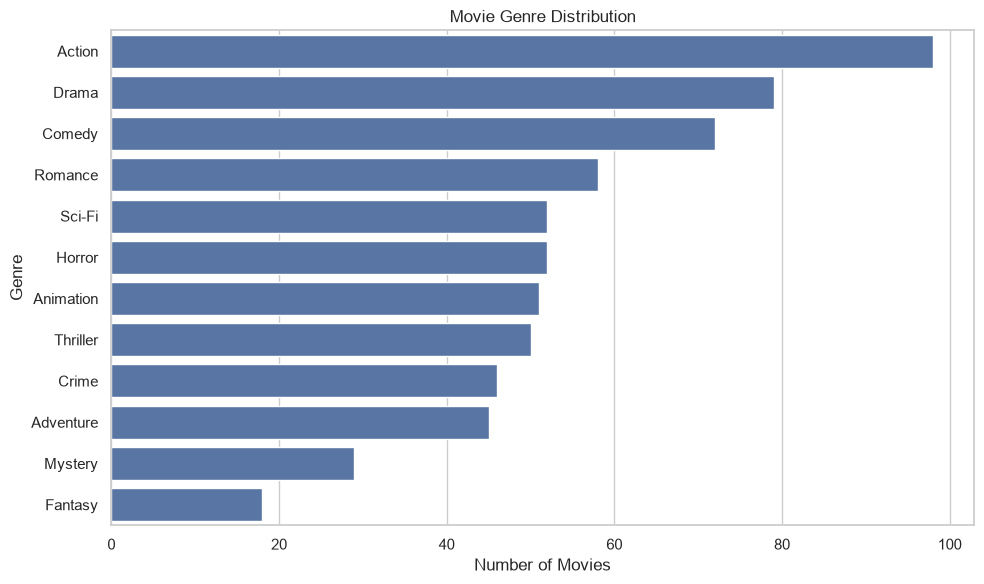

In [3]:
genres = df["Genre"].dropna().astype(str).str.split(",").explode().str.strip()
genre_counts = genres.value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Insight:** This chart shows which genres are most represented in the dataset.

## 3. Average Rating by Genre

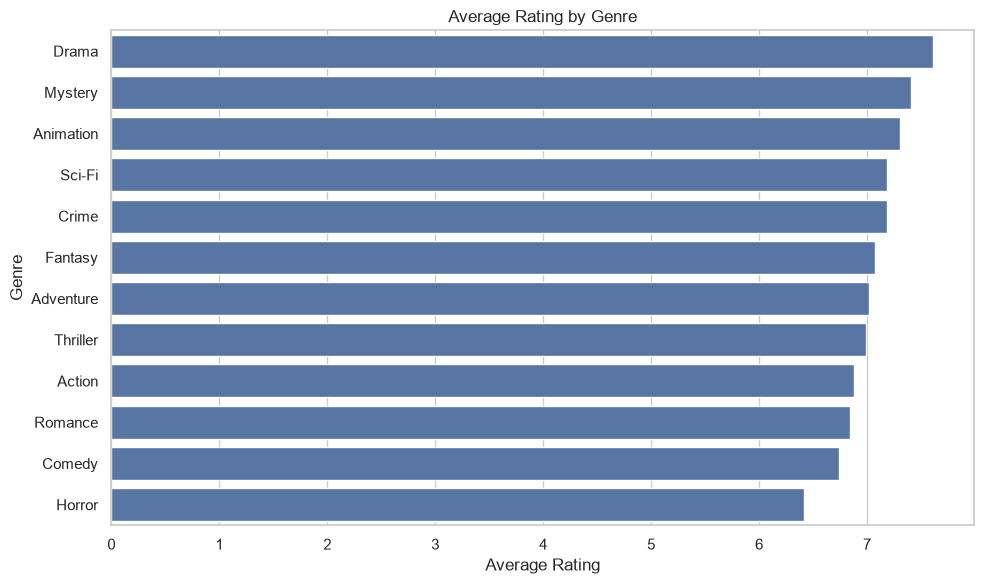

In [4]:
gr = df[["Genre","Rating"]].dropna().copy()
gr["Genre"] = gr["Genre"].astype(str).str.split(",")
gr = gr.explode("Genre")
gr["Genre"] = gr["Genre"].str.strip()

avg_rating = gr.groupby("Genre")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Insight:** This comparison identifies the genres with higher and lower average ratings within this dataset.

## 4. Movie Releases by Year

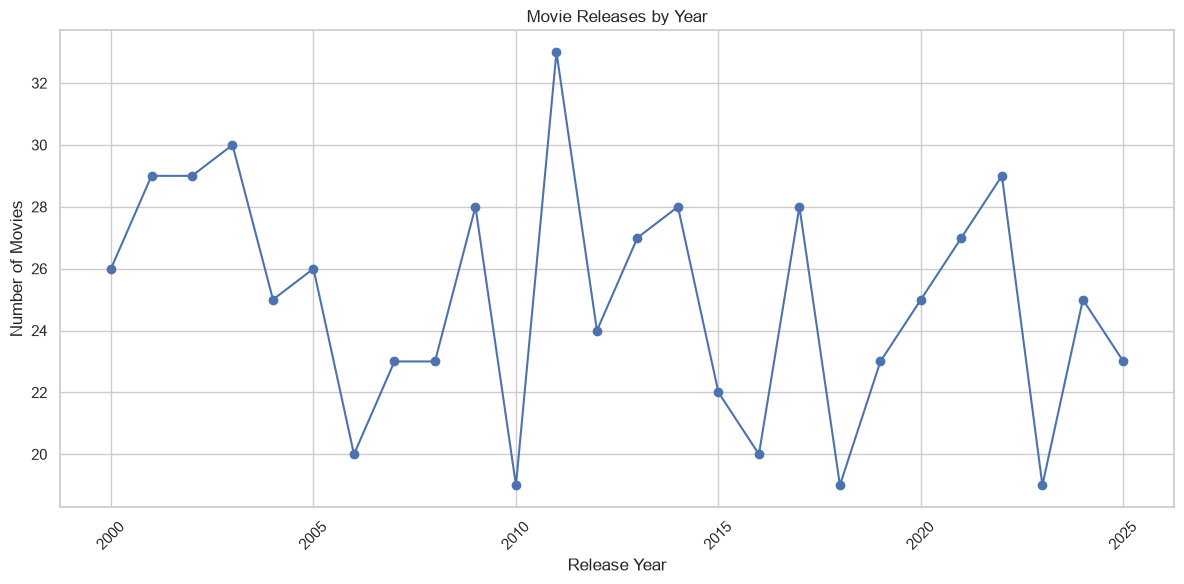

Most represented year: 2011
Movies in that year: 33


In [5]:
year_counts = df["Release_Year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Movie Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Most represented year:", year_counts.idxmax())
print("Movies in that year:", year_counts.max())

**Insight:** The peak year is the year containing the largest number of movies in the provided dataset.

## 5. Rating Distribution

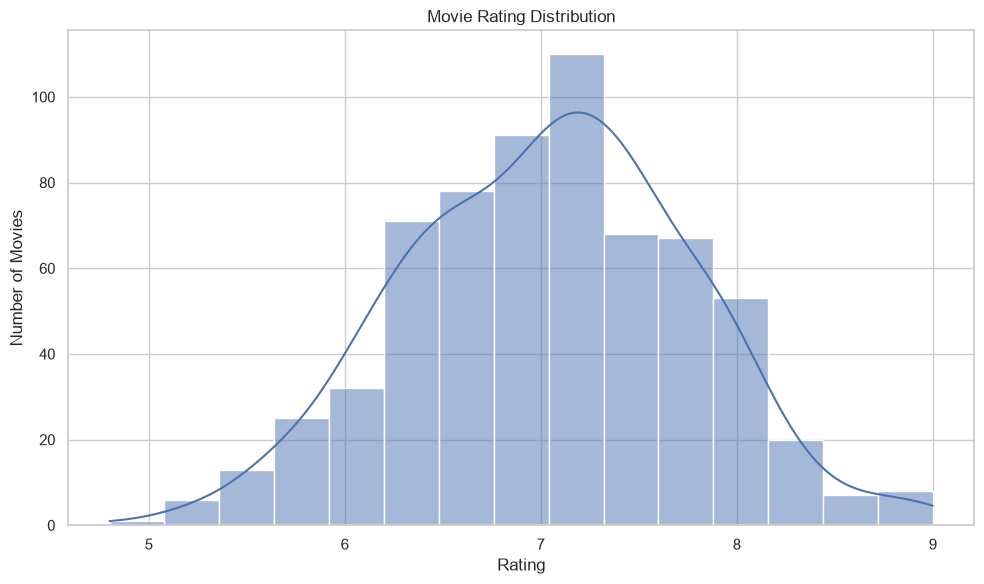

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df["Rating"].dropna(), bins=15, kde=True)
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

**Insight:** The histogram shows how movie ratings are distributed across the dataset.

## 6. Top 10 Highest-Rated Movies

,Title,Rating
24,Wild Stars,9.0
238,Echo Road,9.0
97,Hidden Legacy,9.0
614,Golden Game,8.9
103,Northern World,8.9
55,American Future,8.9
513,Infinite Hearts,8.8
410,Wild Dream,8.8
96,Forgotten Truth,8.7
157,Rising Journey,8.7


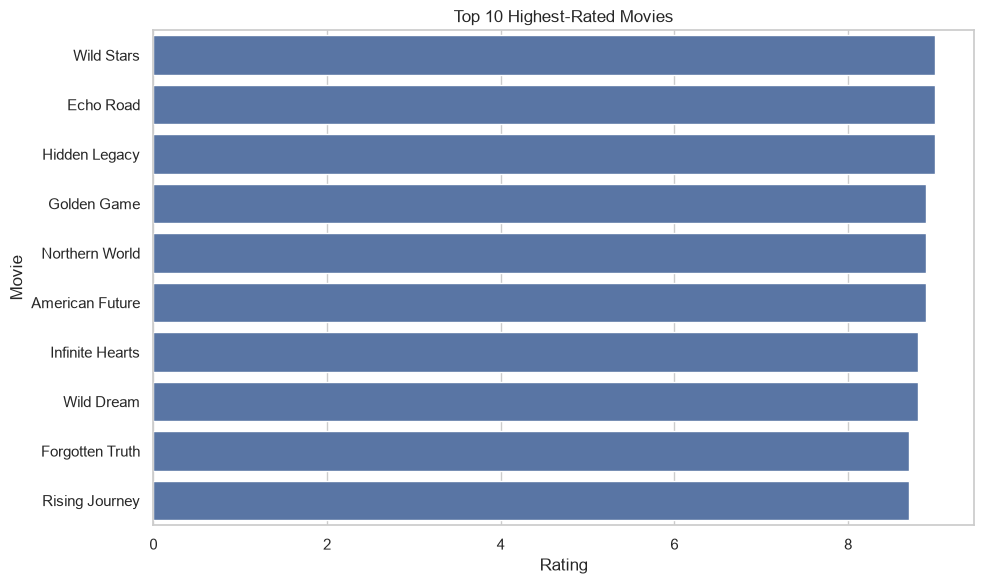

In [7]:
top10 = df[["Title","Rating"]].dropna().sort_values("Rating", ascending=False).head(10)
display(top10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Rating", y="Title")
plt.title("Top 10 Highest-Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

**Insight:** This chart highlights the 10 highest-rated movies in the supplied dataset.

## 7. Rating vs. Vote Count

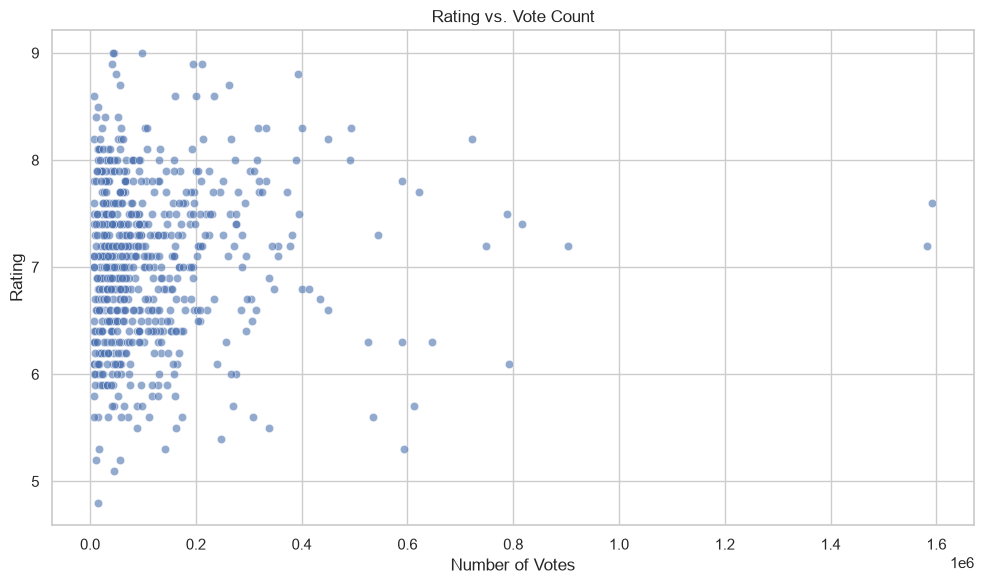

Correlation: 0.073


In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Votes", y="Rating", alpha=0.6)
plt.title("Rating vs. Vote Count")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

correlation = df[["Votes","Rating"]].corr().iloc[0,1]
print("Correlation:", round(correlation, 3))

**Insight:** The scatter plot explores the association between the number of votes and movie ratings. Correlation does not imply causation.

# Final Summary
- Analyzed 650 movie records.
- Examined genre distribution.
- Compared average ratings by genre.
- Identified the most represented release year.
- Studied the rating distribution.
- Identified the top 10 highest-rated movies.
- Explored the relationship between ratings and vote counts.

**Conclusion:** Python visualization provides a clear way to explore patterns and summarize movie-rating data.